In [94]:
#Youtube video link:

#Learning from teachers code: 
#1)make use of OOPS structute, make functions, modularize the code
#2)for classification model: Make use of Random Forest cLassifier over Logistic REgression
#because Random Forest classifier can classify both linear and non linear data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## Data Gathering

In [97]:
df=pd.read_csv("Finance.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [99]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# Data Imputation

In [102]:
# 1. Categorical Columns - Fill with Mode
# We use [0] because .mode() returns a Series
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# 2. Numerical Columns - Fill with Median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

# 3. Special Case: Credit_History
# Even though it looks like numbers (0 and 1), it is actually categorical.
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)


In [104]:

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [106]:
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print((cat_features))

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


## Train Test Split

In [109]:
df['Loan_ID'] = range(1, len(df) + 1)  
#we can either drop the loan ID , or here i have simply converted it to whole numbers

X=df.drop(["Loan_Status"],axis=1)
y=df["Loan_Status"]
y = y.map({'Y': 1, 'N': 0})  #Encoding y here only

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.3, random_state=42)

## Data Encoding for categorical columns and Standardization for numerical columns

In [112]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

scaler=StandardScaler()
OHE = OneHotEncoder(drop='first')   #The first column of OneHotEncoder is always a waste
OE=OrdinalEncoder()

# Define which columns go where
ordinal_cols = ['Education', 'Gender', 'Married']
nominal_cols = ['Property_Area', 'Self_Employed']
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

preprocessor= ColumnTransformer(
     [
         ("OneHotEncoder", OHE, nominal_cols ),        #what are we applying and where are we applying
          ("OrdinalEncoder",OE,ordinal_cols),
          ("StandardScaler", scaler, numerical_cols)
    ]
)



In [114]:
#Train the model with this preprocessor(Applying tranformation in training dataset)
X_train= preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)
#all the categorical features get converted to arrays


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [116]:
models={
    "RandomForestClassifier": RandomForestClassifier(),
    "LogisticRegression": LogisticRegression()
}

for i in range(len(list(models))):
    model = list(models.values())[i]  #It's like picking the "next MODEL" out of a LIST so you can use it.
    #1)Train
    model.fit(X_train, y_train) # Train model

    #2)Make predictions on that particular model
    y_pred = model.predict(X_test)

    #3)Performance metric (always between y_pred and y_test)
    model_test_accuracy = accuracy_score(y_test, y_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_pred) #Calculate Roc

    #Display the name of the model you are using
    print(list(models.keys())[i])

    #Now print everything u collected
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
    

RandomForestClassifier
Model performance for Test set
- Accuracy: 0.6108
- F1 score: 0.5355
- Precision: 0.6446
- Recall: 0.8917
- Roc Auc Score: 0.4920
LogisticRegression
Model performance for Test set
- Accuracy: 0.6541
- F1 score: 0.5319
- Precision: 0.6538
- Recall: 0.9917
- Roc Auc Score: 0.5112


<Axes: >

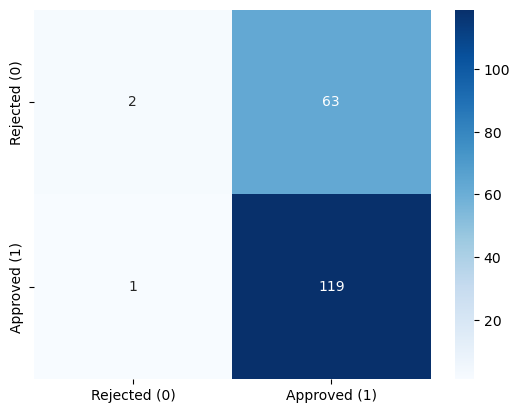

In [118]:
#Visualisation for classification models generally
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plot it nicely using Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'])

In [120]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

# Feature Importance
## (New concept that i learned- Only for Random Forest classifier)

In [123]:
#Tells you about how important was each feature in model training

importances = pd.DataFrame(model.feature_importances_)
importances['features'] = features
importances.columns = ['importance','feature']
importances.sort_values(by = 'importance', ascending= True,inplace=True)

import matplotlib.pyplot as plt
plt.barh(importances.feature, importances.importance)

AttributeError: 'LogisticRegression' object has no attribute 'feature_importances_'